In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import get_dataset, prepare_df
from src.pipeline import get_preprocessor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from src.metrics import metrics
import joblib

In [2]:
df = get_dataset()

In [3]:
X_train, X_test, y_train, y_test = prepare_df(df)

In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(5634, 19)
(5634,)
(1409, 19)
(1409,)


In [5]:
preprocessor = get_preprocessor()

In [6]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [7]:
params_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_features": ["sqrt", "log2", 0.2, 0.3],
    "model__bootstrap": [True],
    "model__max_depth": [None, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 10],
    "model__criterion": ["entropy", "gini"],
    "model__class_weight": ["balanced", "balanced_subsample", None]
}

In [8]:
random_search = RandomizedSearchCV(pipe, param_distributions=params_grid, random_state=42, scoring="recall", verbose=1, n_jobs=1)

In [9]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True], 'model__class_weight': ['balanced', 'balanced_subsample', ...], 'model__criterion': ['entropy', 'gini'], 'model__max_depth': [None, 10, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-va

TRAINING
Accuracy score: 0.8161164359247426
recall score: 0.8602006688963211
precision score: 0.6086133459536205
f1 score: 0.7128603104212861
ROC-AUC score: 0.9136590438774331
Classification Report
              precision    recall  f1-score   support

           0       0.94      0.80      0.86      4139
           1       0.61      0.86      0.71      1495

    accuracy                           0.82      5634
   macro avg       0.77      0.83      0.79      5634
weighted avg       0.85      0.82      0.82      5634



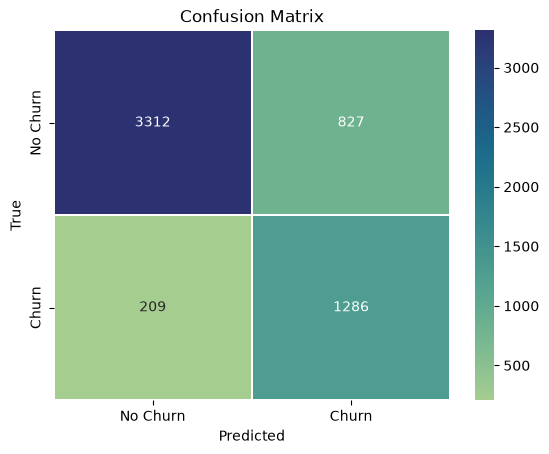

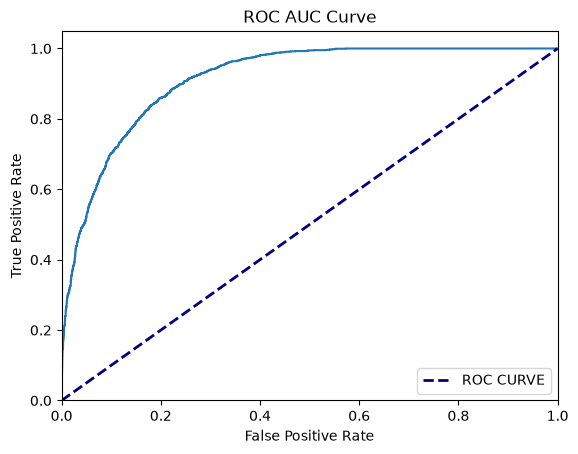

TESTING
Accuracy score: 0.7735982966643009
recall score: 0.7834224598930482
precision score: 0.551789077212806
f1 score: 0.6475138121546962
ROC-AUC score: 0.8527319228086492
Classification Report
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1035
           1       0.55      0.78      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409



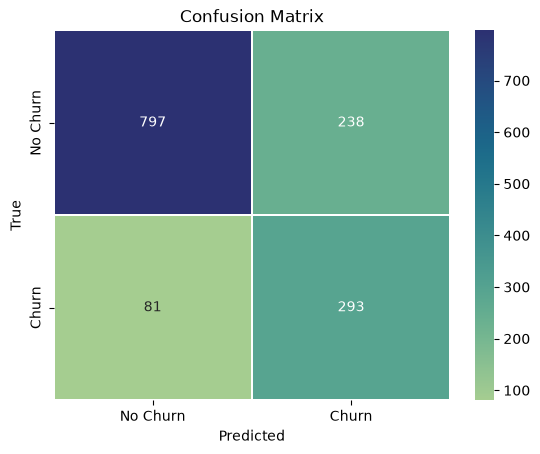

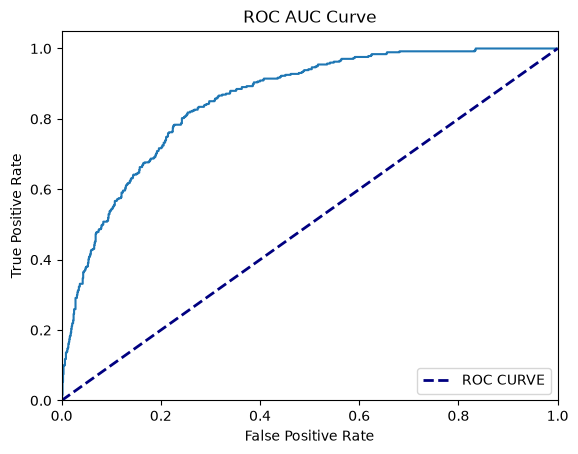

In [10]:
print("TRAINING")
y_pred_train = random_search.predict(X_train)
y_pred_train_proba = random_search.predict_proba(X_train)
metrics(y_train, y_pred_train, y_pred_train_proba[:, 1])


print("TESTING")
y_pred = random_search.predict(X_test)
y_pred_proba = random_search.predict_proba(X_test)
metrics(y_test, y_pred, y_pred_proba[:, 1])

In [11]:
random_search.cv_results_

{'mean_fit_time': array([0.13428831, 0.31448483, 0.31066718, 0.48654685, 0.19122462,
        0.19155788, 0.3034698 , 0.32414508, 0.32946978, 0.31951623]),
 'std_fit_time': array([0.01313617, 0.01714271, 0.00352889, 0.00325439, 0.00230728,
        0.00143744, 0.00185415, 0.0033275 , 0.0013823 , 0.02898652]),
 'mean_score_time': array([0.02295375, 0.04787631, 0.0477334 , 0.06513329, 0.022054  ,
        0.02187371, 0.04714322, 0.04782686, 0.04695082, 0.04741907]),
 'std_score_time': array([0.00234276, 0.00104044, 0.00065354, 0.00551249, 0.00119383,
        0.00095385, 0.00145683, 0.00086321, 0.00099228, 0.00043406]),
 'param_model__n_estimators': masked_array(data=[100, 300, 300, 500, 100, 100, 300, 300, 300, 300],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value=999999),
 'param_model__min_samples_split': masked_array(data=[20, 20, 10, 5, 20, 5, 5, 2, 5, 10],
              mask=[False, False, False, False, F

In [12]:
random_search.best_params_

{'model__n_estimators': 100,
 'model__min_samples_split': 20,
 'model__min_samples_leaf': 10,
 'model__max_features': 0.2,
 'model__max_depth': 15,
 'model__criterion': 'gini',
 'model__class_weight': 'balanced_subsample',
 'model__bootstrap': True}

In [13]:
joblib.dump(random_search, "models/randomforest.joblib")

['models/randomforest.joblib']

In [14]:
model = joblib.load("models/randomforest.joblib")

Accuracy score: 0.7735982966643009
recall score: 0.7834224598930482
precision score: 0.551789077212806
f1 score: 0.6475138121546962
ROC-AUC score: 0.8527319228086492
Classification Report
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1035
           1       0.55      0.78      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409



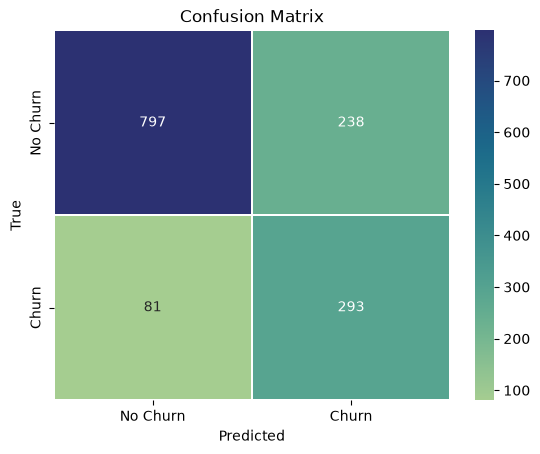

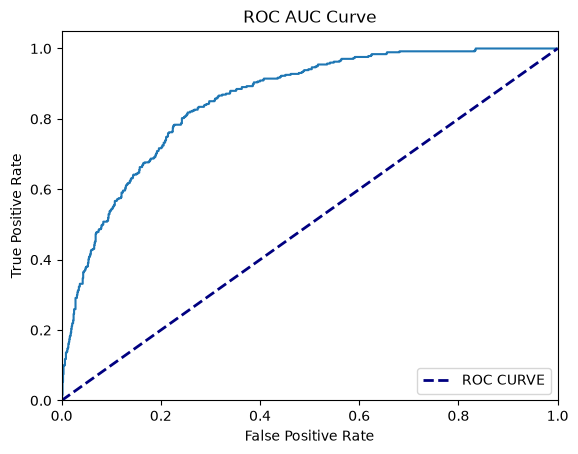

In [15]:
y_pred1 = model.predict(X_test)
y_pred_proba1 = model.predict_proba(X_test)
metrics(y_test, y_pred1, y_pred_proba1[:, 1])